# Marketing Mix Model
- Justin Wall, Senior Data Scientist, Arclight Cycling
## Questions to answer
1. Which channels drive revenue? Channel decomposition + ROAS posteriors
2. Are we overspending anywhere? Saturation curves per channel
3. Where should we shift $500K? Budget reallocation optimizer
4. How long does advertising stick? Adstock decay estimates
5. How confident should we be? Posterior credible intervals

### Data Description
- 156 weeks (3 years, 2022–2024), enough history for seasonality and trend
- 5 channels: paid search, social, email, display, TV
- Realistic spend patterns: TV is bursty/seasonal, paid search is always-on, email is low-cost high-frequency, display is moderate, social ramps up over time
- Ground truth baked in: the data-generating process is intentional so paid search is genuinely over-saturated, TV has long adstock decay, email has high ROAS but low ceiling, and social is the underinvested channel, which will make the budget optimizer recommendation interesting and defensible
- Confounders included: seasonality (cycling is Q1/Q2 heavy), a trend, and some noise

In [ ]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)

# ── Time index ────────────────────────────────────────────────────────────────
n = 156  # 3 years of weekly data
dates = pd.date_range("2022-01-03", periods=n, freq="W-MON")
week_of_year = dates.isocalendar().week.to_numpy().astype(float)
year_idx = (dates.year - 2022).to_numpy().astype(float)  # 0, 1, 2

# ── Seasonality (cycling peaks Jan–Apr, secondary Oct) ────────────────────────
seasonality = (
    1.20 * np.sin(2 * np.pi * (week_of_year - 4) / 52)   # primary Jan/Feb peak
  + 0.25 * np.sin(4 * np.pi * (week_of_year - 4) / 52)   # secondary harmonic
)

# ── Long-run trend (modest 8% annual revenue growth) ─────────────────────────
trend = 0.0015 * np.arange(n)

# ── Spend patterns ────────────────────────────────────────────────────────────
# Paid search: always-on, gradually increasing, heavy Q1
paid_search = (
    18_000
    + 4_000 * year_idx
    + 6_000 * np.clip(np.sin(2 * np.pi * (week_of_year - 4) / 52), 0, None)
    + rng.normal(0, 1_500, n)
).clip(8_000)

# Social: low early, ramps significantly by year 3, spiky campaigns
social_base = 8_000 + 5_000 * year_idx
campaign_spikes = rng.choice([0, 1], size=n, p=[0.75, 0.25]) * rng.uniform(5_000, 15_000, n)
social = (social_base + campaign_spikes + rng.normal(0, 1_000, n)).clip(2_000)

# Email: low spend, consistent, slight Q1 push (cost = deployment + creative)
email = (
    2_500
    + 800 * np.clip(np.sin(2 * np.pi * (week_of_year - 6) / 52), 0, None)
    + rng.normal(0, 300, n)
).clip(1_000)

# Display: moderate, always-on retargeting, modest growth
display = (
    9_000
    + 1_500 * year_idx
    + rng.normal(0, 1_200, n)
).clip(4_000)

# TV: bursty — two flights per year (Q1 brand push + Q4 holiday), else zero
tv = np.zeros(n)
for yr in range(3):
    base_week = yr * 52
    # Q1 flight: weeks 2–8
    q1 = np.arange(base_week + 2, min(base_week + 9, n))
    tv[q1] = rng.uniform(60_000, 120_000, len(q1))
    # Q4 flight: weeks 40–47
    q4 = np.arange(base_week + 40, min(base_week + 48, n))
    tv[q4] = rng.uniform(50_000, 100_000, len(q4))

# ── Adstock transformations ───────────────────────────────────────────────────
def adstock(x, decay):
    """Geometric adstock — carryover effect of advertising."""
    out = np.zeros_like(x, dtype=float)
    out[0] = x[0]
    for t in range(1, len(x)):
        out[t] = x[t] + decay * out[t - 1]
    return out

paid_search_adstocked = adstock(paid_search, decay=0.3)   # short memory
social_adstocked       = adstock(social,      decay=0.4)   # moderate
email_adstocked        = adstock(email,        decay=0.2)   # very short
display_adstocked      = adstock(display,      decay=0.35)  # moderate
tv_adstocked           = adstock(tv,           decay=0.7)   # long brand halo

# ── Hill (saturation) transformation ─────────────────────────────────────────
def hill(x, k, n_hill):
    """Hill function: diminishing returns. k = half-saturation point."""
    return x**n_hill / (k**n_hill + x**n_hill)

# Normalize each channel to [0, spend_scale] before Hill so k is interpretable
def hill_scaled(x, k_pct=0.6, n_hill=2.0):
    """k as percentile of observed spend, so saturation is data-relative."""
    k = np.percentile(x[x > 0], k_pct * 100)
    return hill(x, k, n_hill)

ps_sat   = hill_scaled(paid_search_adstocked, k_pct=0.45, n_hill=3.0)  # heavy saturation
soc_sat  = hill_scaled(social_adstocked,       k_pct=0.75, n_hill=1.8)  # under-saturated
em_sat   = hill_scaled(email_adstocked,         k_pct=0.55, n_hill=2.2)
disp_sat = hill_scaled(display_adstocked,       k_pct=0.60, n_hill=2.0)
tv_sat   = hill_scaled(tv_adstocked,            k_pct=0.65, n_hill=1.5)  # linear-ish (bursty)

# ── Revenue DGP ───────────────────────────────────────────────────────────────
# Coefficients represent max incremental revenue contribution (at full saturation)
# Paid search: high absolute but heavily saturated → low marginal ROAS
# Social: moderate spend but under-saturated → high marginal ROAS
# Email: tiny spend, great marginal ROAS, low ceiling
# TV: big brand halo, hard to attribute short-term
BASELINE = 280_000   # weekly baseline revenue (zero-marketing floor)

revenue = (
    BASELINE
    + 80_000  * ps_sat       # paid search — large coef but flattened
    + 70_000  * soc_sat      # social — meaningful, still on steep part of curve
    + 40_000  * em_sat       # email — punches above its weight
    + 35_000  * disp_sat     # display — supporting role
    + 90_000  * tv_sat       # TV — biggest max effect, long decay
    + 60_000  * seasonality  # seasonal swing
    + 15_000  * trend        # growth trend
    + rng.normal(0, 12_000, n)  # noise
)

# ── Assemble dataframe ────────────────────────────────────────────────────────
df = pd.DataFrame({
    "week":         dates,
    "revenue":      revenue.round(2),
    "spend_paid_search": paid_search.round(2),
    "spend_social":      social.round(2),
    "spend_email":       email.round(2),
    "spend_display":     display.round(2),
    "spend_tv":          tv.round(2),
})

df.to_csv("../data/arclight_mmm_data.csv", index=False)
print(df.describe().round(0).to_string())
print(f"\nTotal rows: {len(df)}")
print(f"Date range: {df.week.min().date()} → {df.week.max().date()}")
print(f"\nMean weekly revenue:     ${df.revenue.mean():,.0f}")
print(f"Mean weekly total spend: ${(df[['spend_paid_search','spend_social','spend_email','spend_display','spend_tv']].sum(axis=1).mean()):,.0f}")

                      week   revenue  spend_paid_search  spend_social  spend_email  spend_display  spend_tv
count                  156     156.0              156.0         156.0        156.0          156.0     156.0
mean   2023-06-29 12:00:00  415868.0            23819.0       15678.0       2731.0        10428.0   23666.0
min    2022-01-03 00:00:00  277597.0            15797.0        5927.0       1804.0         6856.0       0.0
25%    2022-10-01 06:00:00  366490.0            20607.0       11853.0       2402.0         9219.0       0.0
50%    2023-06-29 12:00:00  405294.0            23664.0       15312.0       2691.0        10492.0       0.0
75%    2024-03-26 18:00:00  463186.0            26642.0       18740.0       3049.0        11599.0   60899.0
max    2024-12-23 00:00:00  570690.0            34228.0       32077.0       3992.0        14472.0  116401.0
std                    NaN   62926.0             4170.0        6135.0        457.0         1645.0   38402.0

Total rows: 156
Date range:

: 

## Step 1 -> Data Alignment
Align with key stakeholders on the base data before going further. Is what we see here what is expected from each channel? Meet with channel owners and learn about intricacies in the data, create an event log to help inform the eventual model. We will show them a few graphs up front: 1) Spend & Revenue over time, 2) Channel spend composition over time, 3) Any limitations or issues in the data

In [2]:
# ── Cell 1: Imports & Load ────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.family":      "sans-serif",
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

df = pd.read_csv("../data/arclight_mmm_data.csv", parse_dates=["week"])

CHANNELS = ["spend_paid_search", "spend_social", "spend_email", "spend_display", "spend_tv"]
LABELS   = ["Paid Search", "Social", "Email", "Display", "TV"]
COLORS   = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

df["total_spend"] = df[CHANNELS].sum(axis=1)

print(f"Rows: {len(df)}  |  {df.week.min().date()} → {df.week.max().date()}")
df[["revenue", "total_spend"] + CHANNELS].describe().round(0)

Rows: 156  |  2022-01-03 → 2024-12-23


,revenue,total_spend,spend_paid_search,spend_social,spend_email,spend_display,spend_tv
count,156.0,156.0,156.0,156.0,156.0,156.0,156.0
mean,415868.0,76322.0,23819.0,15678.0,2731.0,10428.0,23666.0
std,62926.0,38318.0,4170.0,6135.0,457.0,1645.0,38402.0
min,277597.0,35362.0,15797.0,5927.0,1804.0,6856.0,0.0
25%,366490.0,48634.0,20607.0,11853.0,2402.0,9219.0,0.0
50%,405294.0,60042.0,23664.0,15312.0,2691.0,10492.0,0.0
75%,463186.0,111798.0,26642.0,18740.0,3049.0,11599.0,60899.0
max,570690.0,176053.0,34228.0,32077.0,3992.0,14472.0,116401.0


***
**Notes:** Weekly data from 1/3/2022 to 12/23/2024. Some 0's in TV.
***
***

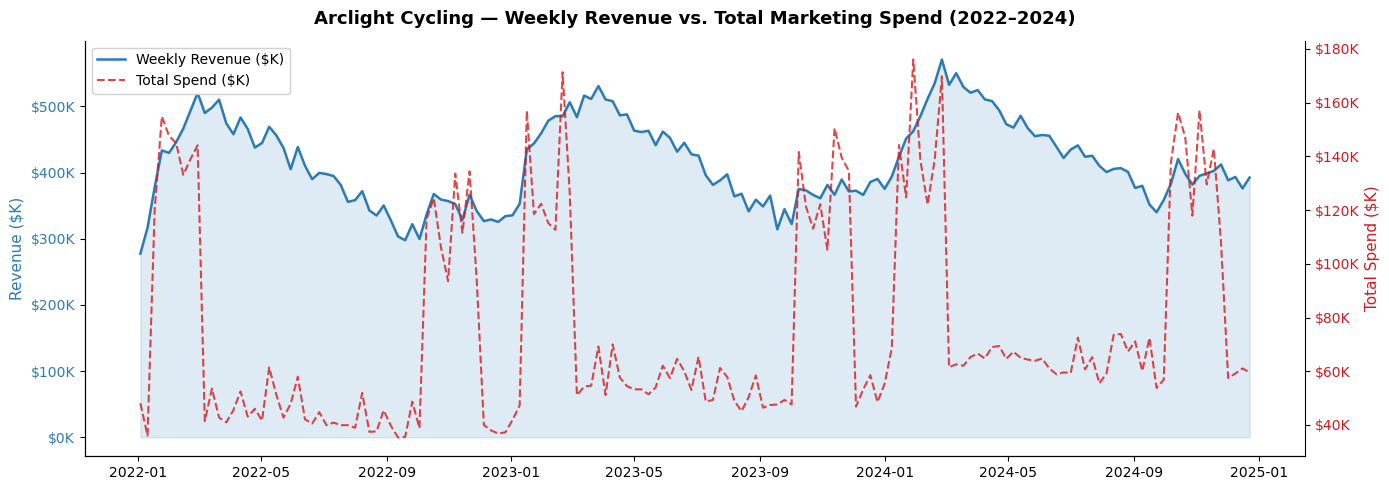

In [3]:
# ── Cell 2: Revenue & Total Spend Over Time ───────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.fill_between(df.week, df.revenue / 1e3, alpha=0.15, color="#2c7bb6")
ax1.plot(df.week, df.revenue / 1e3, color="#2c7bb6", lw=1.8, label="Weekly Revenue ($K)")
ax1.set_ylabel("Revenue ($K)", color="#2c7bb6")
ax1.tick_params(axis="y", labelcolor="#2c7bb6")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

ax2 = ax1.twinx()
ax2.plot(df.week, df.total_spend / 1e3, color="#d7191c", lw=1.5,
         linestyle="--", alpha=0.8, label="Total Spend ($K)")
ax2.set_ylabel("Total Spend ($K)", color="#d7191c")
ax2.tick_params(axis="y", labelcolor="#d7191c")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax2.spines["right"].set_visible(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", framealpha=0.9)

ax1.set_title("Arclight Cycling — Weekly Revenue vs. Total Marketing Spend (2022–2024)",
              fontweight="bold", pad=12)
ax1.set_xlabel("")
fig.tight_layout()
plt.savefig("01_revenue_vs_spend.png", dpi=150, bbox_inches="tight")
plt.show()

***
**Notes:** Over the past 3 years we can see cyclical revenue spikes during spring time when bikes are being purchased for the summer, and small bumps of revenue in line with our ad spend, but we cannot discern causality with this chart. We have 2 periods of marketing spend each year, one around holiday, and one in early spring.
***
***

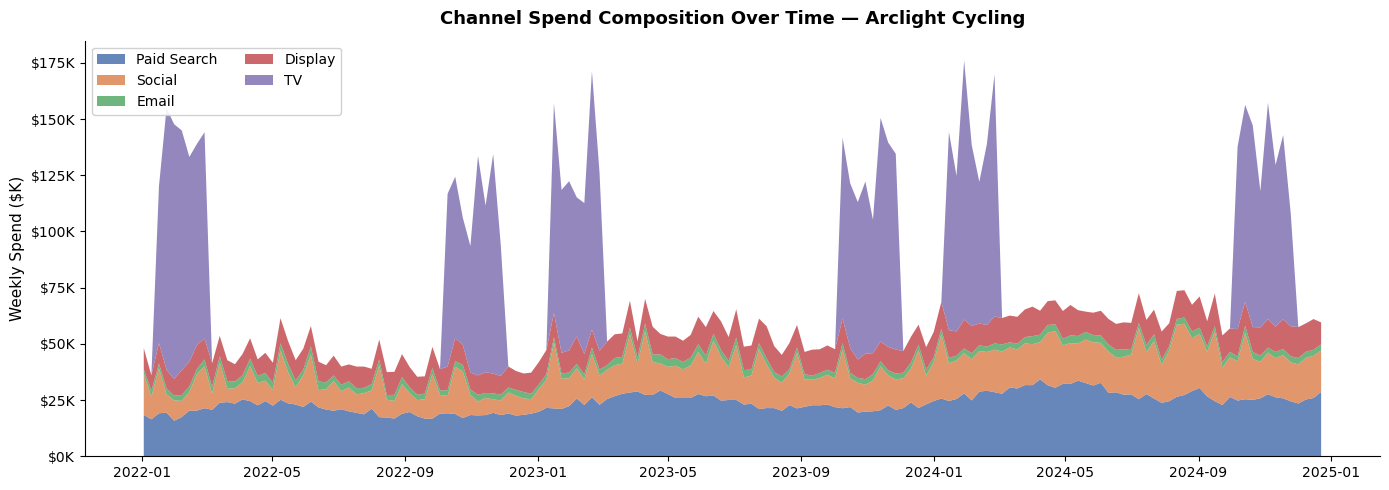

In [4]:
# ── Cell 3: Channel Spend Composition Over Time ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

spend_matrix = df[CHANNELS].values / 1e3
ax.stackplot(df.week, spend_matrix.T, labels=LABELS, colors=COLORS, alpha=0.85)

ax.set_title("Channel Spend Composition Over Time — Arclight Cycling",
             fontweight="bold", pad=12)
ax.set_ylabel("Weekly Spend ($K)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax.legend(loc="upper left", framealpha=0.9, ncol=2)
ax.set_xlabel("")
fig.tight_layout()
plt.savefig("02_channel_composition.png", dpi=150, bbox_inches="tight")
plt.show()

***
**Notes:** The spikes are now clearly related to TV spend, whereas the other channels apperas to just have a general increasing trend with some slight hills throughout the years. Paid search is pretty consistent, as is email. Display & social have increased over the past 3 years.
***
***

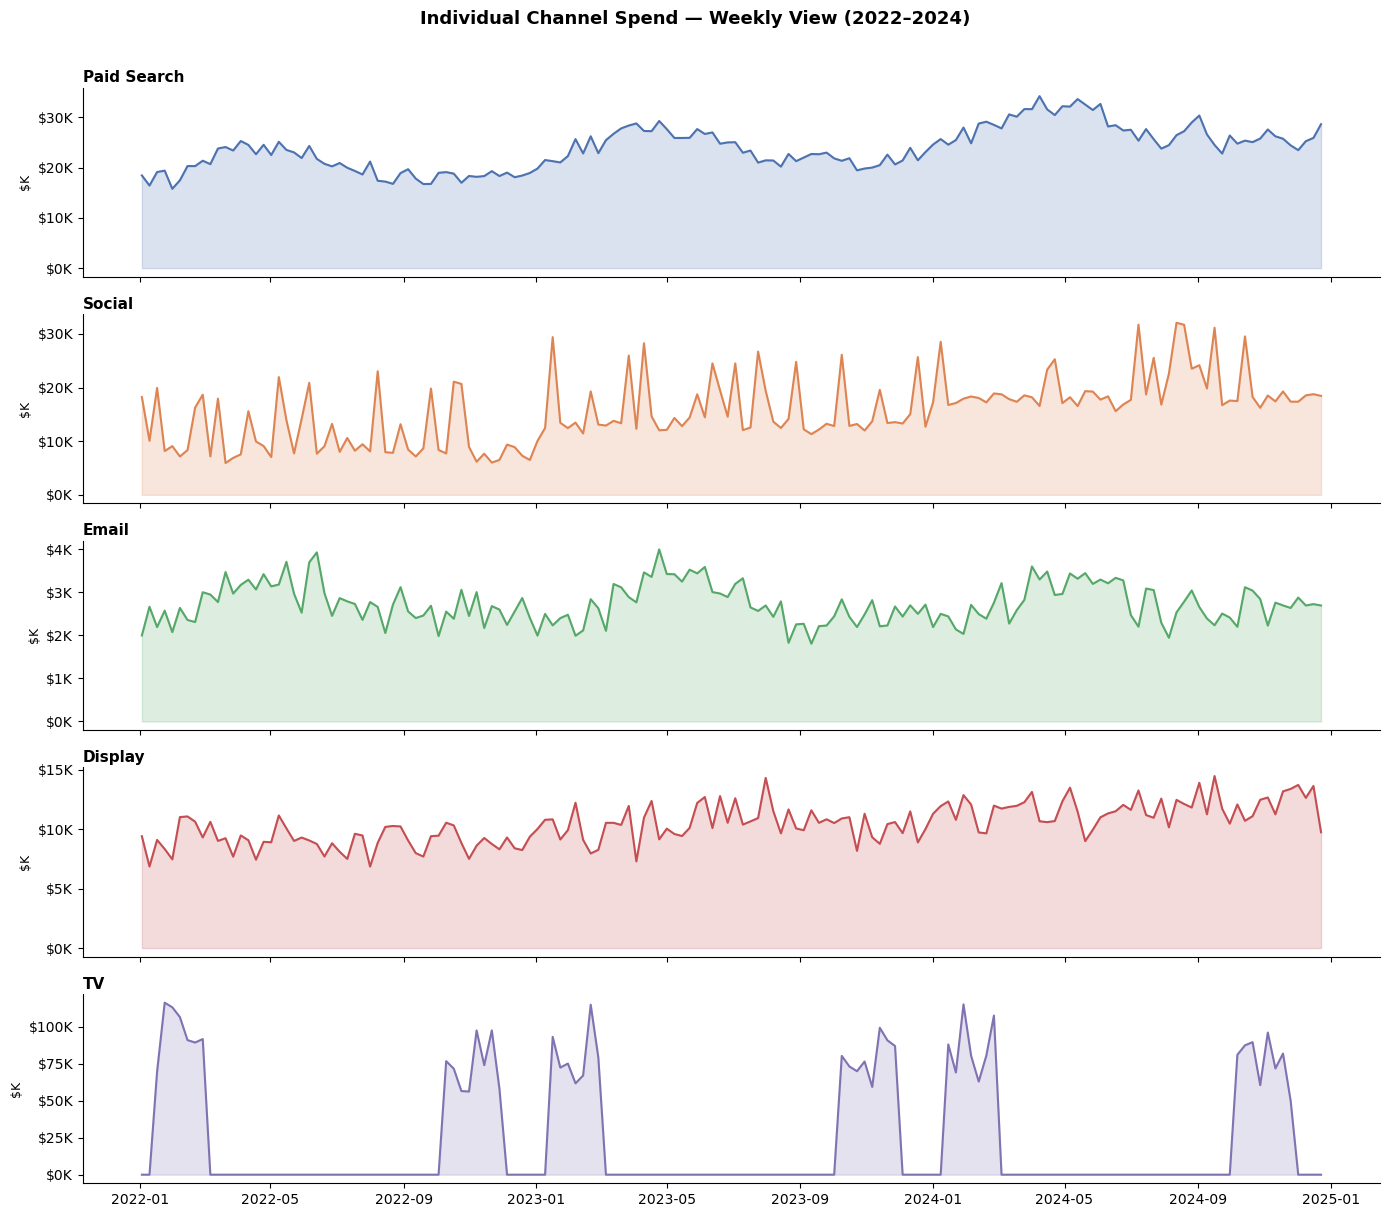

In [5]:
# ── Cell 4: Per-Channel Spend Over Time (Small Multiples) ─────────────────────
fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

for ax, col, label, color in zip(axes, CHANNELS, LABELS, COLORS):
    ax.fill_between(df.week, df[col] / 1e3, alpha=0.2, color=color)
    ax.plot(df.week, df[col] / 1e3, color=color, lw=1.5)
    ax.set_ylabel("$K", fontsize=9)
    ax.set_title(label, fontsize=11, fontweight="bold", loc="left", pad=4)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

axes[-1].set_xlabel("")
fig.suptitle("Individual Channel Spend — Weekly View (2022–2024)",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("03_channel_small_multiples.png", dpi=150, bbox_inches="tight")
plt.show()

***
**Notes:** The seasonality and general increase of paid search is apparant here, as is teh general increase in social over time. Email appears flat to down, and display appears as an increase. TV has some large spikes over time and then completely drops to zero for long periods of time.
***
***

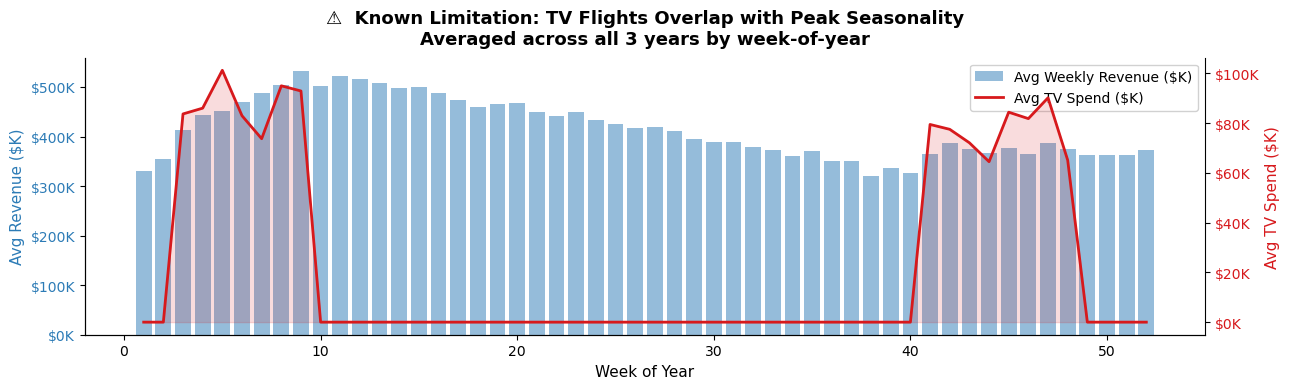


📋 Interpretation note for business team:
TV spend is concentrated in weeks 2–8 (Q1) and weeks 40–47 (Q4),
which happen to be Arclight's strongest revenue weeks regardless of advertising.
The model will need to carefully separate TV's causal effect from natural seasonality.


In [6]:
# ── Cell 5: Honest Limitation — TV vs Seasonality Overlap ─────────────────────
df["week_of_year"] = df.week.dt.isocalendar().week.astype(int)
avg_by_week = df.groupby("week_of_year")[["revenue", "spend_tv"]].mean()

fig, ax1 = plt.subplots(figsize=(13, 4))

ax1.bar(avg_by_week.index, avg_by_week.revenue / 1e3,
        color="#2c7bb6", alpha=0.5, label="Avg Weekly Revenue ($K)")
ax1.set_ylabel("Avg Revenue ($K)", color="#2c7bb6")
ax1.tick_params(axis="y", labelcolor="#2c7bb6")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

ax2 = ax1.twinx()
ax2.plot(avg_by_week.index, avg_by_week.spend_tv / 1e3,
         color="#d7191c", lw=2, label="Avg TV Spend ($K)")
ax2.fill_between(avg_by_week.index, avg_by_week.spend_tv / 1e3,
                 alpha=0.15, color="#d7191c")
ax2.set_ylabel("Avg TV Spend ($K)", color="#d7191c")
ax2.tick_params(axis="y", labelcolor="#d7191c")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax2.spines["right"].set_visible(True)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", framealpha=0.9)

ax1.set_title(
    "⚠️  Known Limitation: TV Flights Overlap with Peak Seasonality\n"
    "Averaged across all 3 years by week-of-year",
    fontweight="bold", pad=10
)
ax1.set_xlabel("Week of Year")
fig.tight_layout()
plt.savefig("04_tv_seasonality_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n📋 Interpretation note for business team:")
print("TV spend is concentrated in weeks 2–8 (Q1) and weeks 40–47 (Q4),")
print("which happen to be Arclight's strongest revenue weeks regardless of advertising.")
print("The model will need to carefully separate TV's causal effect from natural seasonality.")

***
**Notes:** TV spikes are correlated with seasonality. We do TV ads when we know our business is going to ramp up.
***
***

## Step 2 -> Explore Data

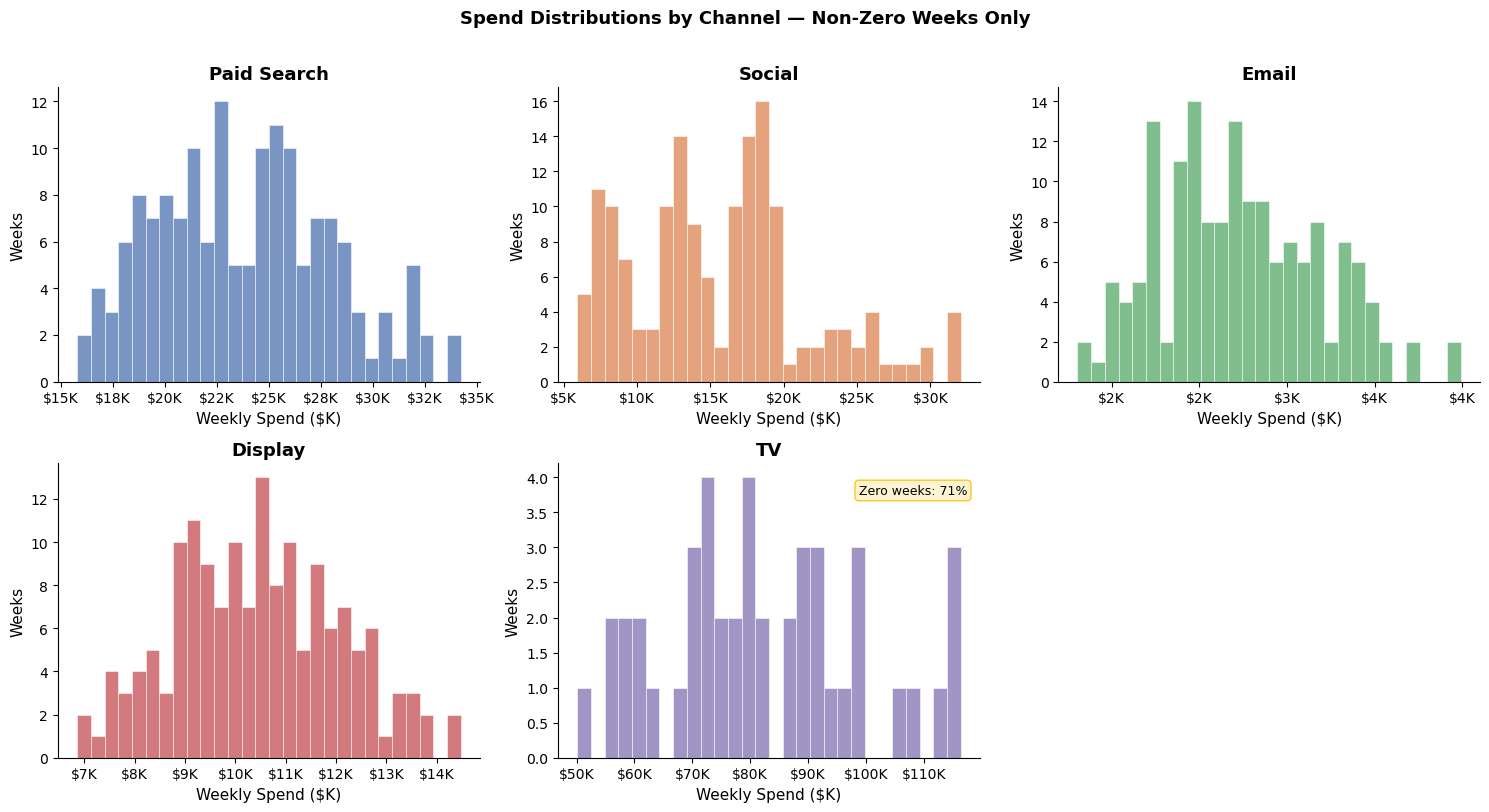

Zero-spend weeks per channel:
  Paid Search      0 of 156 weeks (0%)
  Social           0 of 156 weeks (0%)
  Email            0 of 156 weeks (0%)
  Display          0 of 156 weeks (0%)
  TV             111 of 156 weeks (71%)


In [7]:
# ── Cell 6: Spend Distributions per Channel ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col, label, color in zip(axes, CHANNELS, LABELS, COLORS):
    nonzero = df[col][df[col] > 0]
    ax.hist(nonzero / 1e3, bins=28, color=color, alpha=0.75, edgecolor="white", lw=0.5)
    zero_pct = (df[col] == 0).mean() * 100
    ax.set_title(f"{label}", fontweight="bold")
    ax.set_xlabel("Weekly Spend ($K)")
    ax.set_ylabel("Weeks")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
    note = f"Zero weeks: {zero_pct:.0f}%" if zero_pct > 0 else ""
    if note:
        ax.text(0.97, 0.93, note, transform=ax.transAxes,
                ha="right", va="top", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", fc="#fff3cd", ec="#ffc107", alpha=0.9))

# hide unused 6th panel
axes[5].set_visible(False)
fig.suptitle("Spend Distributions by Channel — Non-Zero Weeks Only",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("05_spend_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# Print zero-week summary
print("Zero-spend weeks per channel:")
for col, label in zip(CHANNELS, LABELS):
    z = (df[col] == 0).sum()
    print(f"  {label:<14} {z:>3} of {len(df)} weeks ({z/len(df)*100:.0f}%)")

***
Notes: Most weeks we spent $0 on TV. Display, search, and email look normally distributed, with email having the lowest variance.

***
***

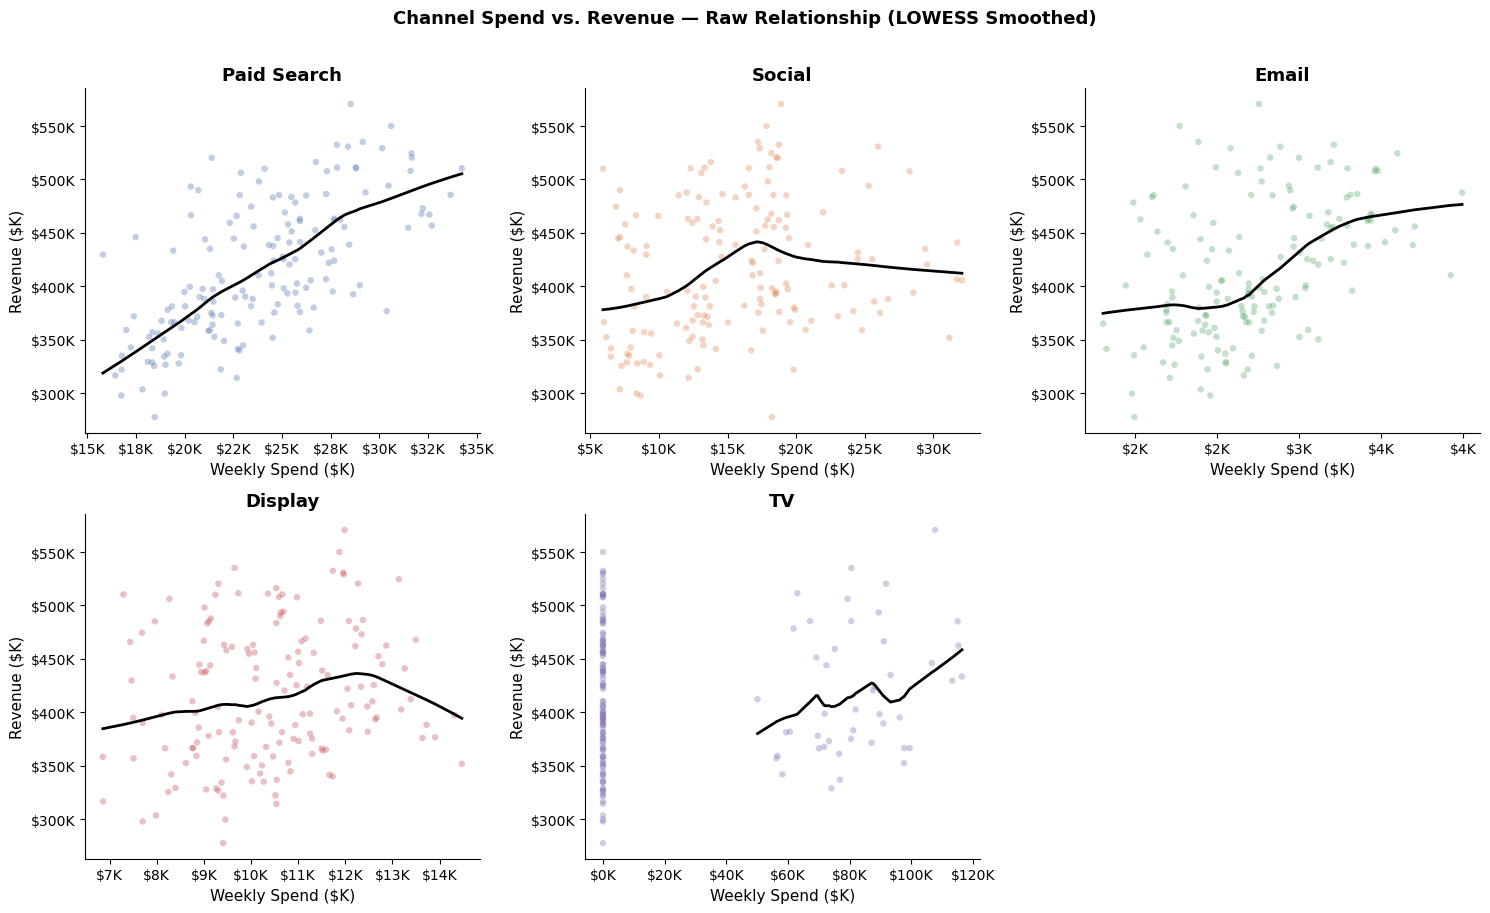

In [9]:
# ── Cell 7: Spend vs. Revenue Scatters (LOWESS) ───────────────────────────────
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, col, label, color in zip(axes, CHANNELS, LABELS, COLORS):
    x = df[col].values / 1e3
    y = df.revenue.values / 1e3
    ax.scatter(x, y, color=color, alpha=0.35, s=22, edgecolors="none")
    # LOWESS only on non-zero spend weeks
    mask = x > 0
    if mask.sum() > 10:
        smoothed = lowess(y[mask], x[mask], frac=0.5, return_sorted=True)
        ax.plot(smoothed[:, 0], smoothed[:, 1], color="black", lw=2, label="LOWESS")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel("Weekly Spend ($K)")
    ax.set_ylabel("Revenue ($K)")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))

axes[5].set_visible(False)
fig.suptitle("Channel Spend vs. Revenue — Raw Relationship (LOWESS Smoothed)",
             fontsize=13, fontweight="bold", y=1.01)
fig.tight_layout()
plt.savefig("06_spend_vs_revenue_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

***
Notes: Paid search appears linear, social flattens at a certain spot, email increases and then flattens, display decreases at a certain spot, tv seems noisy.
***
***

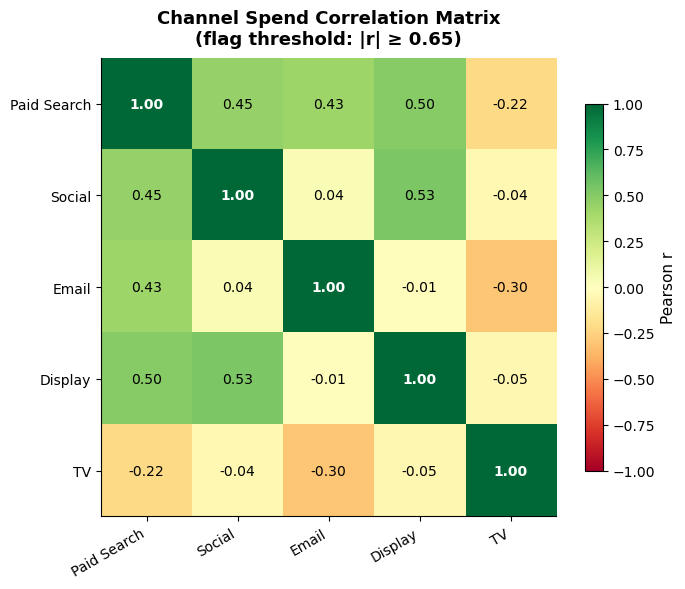

✅ No pairs above correlation threshold.


In [10]:

# ── Cell 8: Correlation Heatmap (Spend Channels Only) ─────────────────────────
spend_df = df[CHANNELS].copy()
spend_df.columns = LABELS
corr = spend_df.corr()

# Flag pairs above threshold
threshold = 0.65
flagged = []
for i in range(len(LABELS)):
    for j in range(i+1, len(LABELS)):
        val = corr.iloc[i, j]
        if abs(val) >= threshold:
            flagged.append((LABELS[i], LABELS[j], val))

fig, ax = plt.subplots(figsize=(7, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # upper triangle only — avoid redundancy
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")

for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        val = corr.iloc[i, j]
        txt_color = "black" if abs(val) < 0.75 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=10, color=txt_color, fontweight="bold" if abs(val) >= threshold else "normal")

ax.set_xticks(range(len(LABELS))); ax.set_xticklabels(LABELS, rotation=30, ha="right")
ax.set_yticks(range(len(LABELS))); ax.set_yticklabels(LABELS)
ax.set_title("Channel Spend Correlation Matrix\n(flag threshold: |r| ≥ 0.65)",
             fontweight="bold", pad=10)
fig.tight_layout()
plt.savefig("07_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

if flagged:
    print("⚠️  Flagged pairs (|r| ≥ 0.65):")
    for a, b, v in flagged:
        print(f"  {a} ↔ {b}: r = {v:.2f}")
else:
    print("✅ No pairs above correlation threshold.")

***
Notes: I don't see anything concerning here, Paid search seems to get funding when everything else does, otherwise no concerning signals here.
***
***

Variance Inflation Factors:
    Channel      VIF Flag
Paid Search 1.923932 ✅ OK
     Social 1.491821 ✅ OK
      Email 1.411604 ✅ OK
    Display 1.656900 ✅ OK
         TV 1.112699 ✅ OK


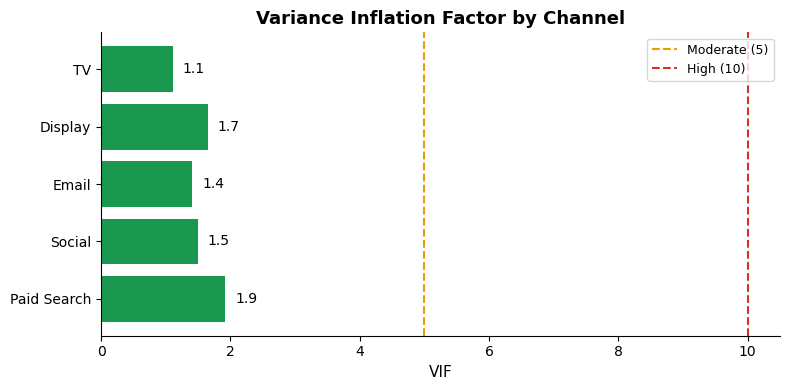

In [11]:

# ── Cell 9: VIF Table ─────────────────────────────────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(df[CHANNELS].values)
vif_data = pd.DataFrame({
    "Channel": ["const"] + LABELS,
    "VIF": [variance_inflation_factor(X_vif, i) for i in range(X_vif.shape[1])]
}).iloc[1:]  # drop intercept row

vif_data["Flag"] = vif_data["VIF"].apply(
    lambda v: "🔴 High — unstable coefficient" if v >= 10
    else ("🟡 Moderate — monitor" if v >= 5 else "✅ OK")
)

print("Variance Inflation Factors:")
print(vif_data.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(vif_data["Channel"], vif_data["VIF"],
               color=["#d73027" if v >= 10 else "#fee08b" if v >= 5 else "#1a9850"
                      for v in vif_data["VIF"]])
ax.axvline(5,  color="#e69f00", lw=1.5, linestyle="--", label="Moderate (5)")
ax.axvline(10, color="#d73027", lw=1.5, linestyle="--", label="High (10)")
ax.set_xlabel("VIF")
ax.set_title("Variance Inflation Factor by Channel", fontweight="bold")
ax.legend(fontsize=9)
for bar, val in zip(bars, vif_data["VIF"]):
    ax.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}", va="center", fontsize=10)
fig.tight_layout()
plt.savefig("08_vif.png", dpi=150, bbox_inches="tight")
plt.show()

***
Notes: Paid search is close to having a 2 for VIF, which would be an indicator it is related to some other features, but they're all safely uncorrelated.
***
***

Naive baseline R²  : 0.869
Implied zero-mktg baseline: $380.5K / week
Residual std dev   : $22.8K / week


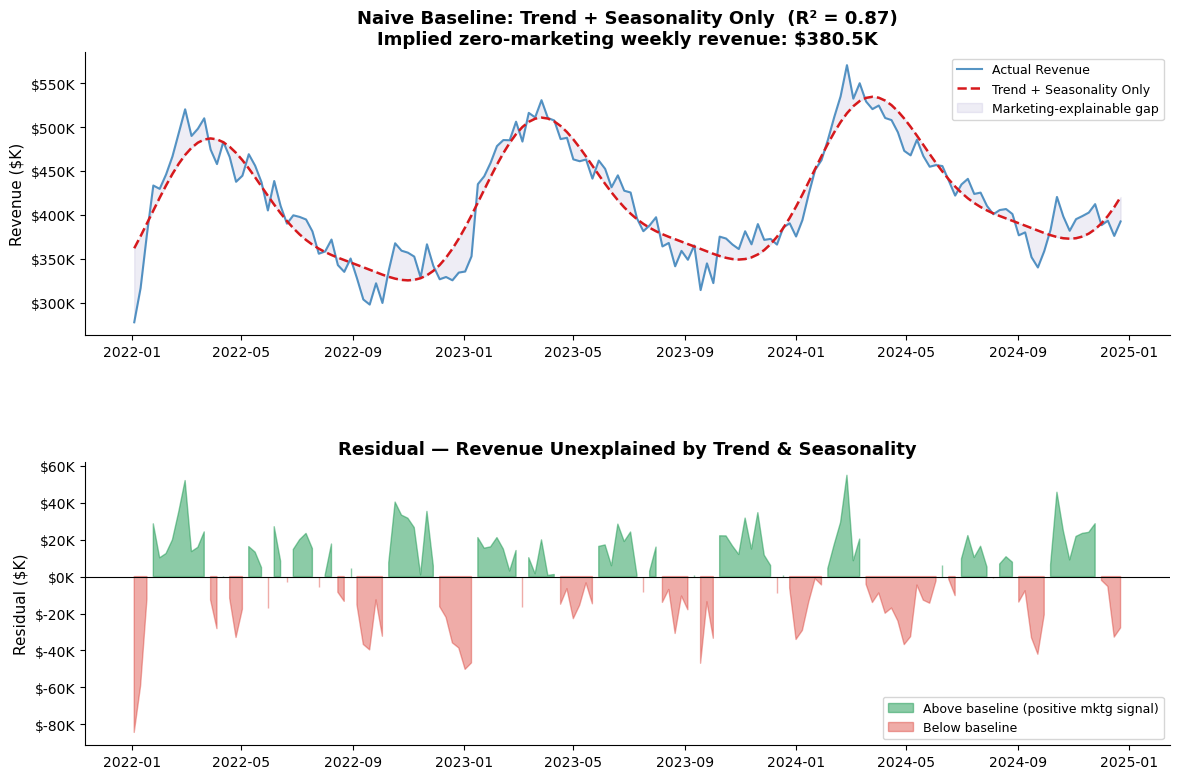


Revenue attribution (rough, pre-model):
  Baseline (trend + seasonality): ~98%
  Potentially marketing-driven:   ~2%


In [12]:

# ── Cell 10: Naive Baseline Decomposition ─────────────────────────────────────
import statsmodels.api as sm

# Fourier terms to capture seasonality (K=2 harmonics ~ annual cycle)
t = np.arange(len(df))
K = 2
fourier = {}
for k in range(1, K + 1):
    fourier[f"sin_{k}"] = np.sin(2 * np.pi * k * t / 52)
    fourier[f"cos_{k}"] = np.cos(2 * np.pi * k * t / 52)

baseline_df = pd.DataFrame(fourier)
baseline_df["trend"] = t / len(df)  # normalized 0→1
X_base = sm.add_constant(baseline_df)
model_base = sm.OLS(df.revenue, X_base).fit()

df["baseline_fitted"] = model_base.fittedvalues
df["baseline_residual"] = model_base.resid

r2 = model_base.rsquared
intercept_k = model_base.params["const"] / 1e3

print(f"Naive baseline R²  : {r2:.3f}")
print(f"Implied zero-mktg baseline: ${intercept_k:,.1f}K / week")
print(f"Residual std dev   : ${df.baseline_residual.std()/1e3:,.1f}K / week")

fig = plt.figure(figsize=(14, 9))
gs = GridSpec(2, 1, figure=fig, hspace=0.45)

# Top: actual vs fitted baseline
ax1 = fig.add_subplot(gs[0])
ax1.plot(df.week, df.revenue / 1e3, color="#2c7bb6", lw=1.5, alpha=0.8, label="Actual Revenue")
ax1.plot(df.week, df.baseline_fitted / 1e3, color="#d7191c", lw=1.8,
         linestyle="--", label="Trend + Seasonality Only")
ax1.fill_between(df.week, df.baseline_fitted / 1e3, df.revenue / 1e3,
                 alpha=0.12, color="#756bb1", label="Marketing-explainable gap")
ax1.set_ylabel("Revenue ($K)")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax1.set_title(f"Naive Baseline: Trend + Seasonality Only  (R² = {r2:.2f})\n"
              f"Implied zero-marketing weekly revenue: ${intercept_k:,.1f}K",
              fontweight="bold")
ax1.legend(fontsize=9)

# Bottom: residual — "marketing signal"
ax2 = fig.add_subplot(gs[1])
ax2.fill_between(df.week, df.baseline_residual / 1e3, 0,
                 where=df.baseline_residual >= 0, color="#1a9850", alpha=0.5,
                 label="Above baseline (positive mktg signal)")
ax2.fill_between(df.week, df.baseline_residual / 1e3, 0,
                 where=df.baseline_residual < 0, color="#d73027", alpha=0.4,
                 label="Below baseline")
ax2.axhline(0, color="black", lw=0.8)
ax2.set_ylabel("Residual ($K)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}K"))
ax2.set_title("Residual — Revenue Unexplained by Trend & Seasonality",
              fontweight="bold")
ax2.legend(fontsize=9)

plt.savefig("09_naive_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

# Revenue split summary
mktg_share = (df.baseline_residual.clip(lower=0).sum() / df.revenue.sum()) * 100
baseline_share = 100 - mktg_share
print(f"\nRevenue attribution (rough, pre-model):")
print(f"  Baseline (trend + seasonality): ~{baseline_share:.0f}%")
print(f"  Potentially marketing-driven:   ~{mktg_share:.0f}%")

***
Notes: We are seeing 87% of variance explained by trend & seasonality, meaning 13% of revenue is explained by marketing spend.
***
***